In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Machine Learning imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
sns.set(style="white", color_codes=True)

drive.mount('/content/drive')
dataset = pd.read_csv('/content/drive/My Drive/Colab Notebooks/datasets/house_price_50k.csv')
dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


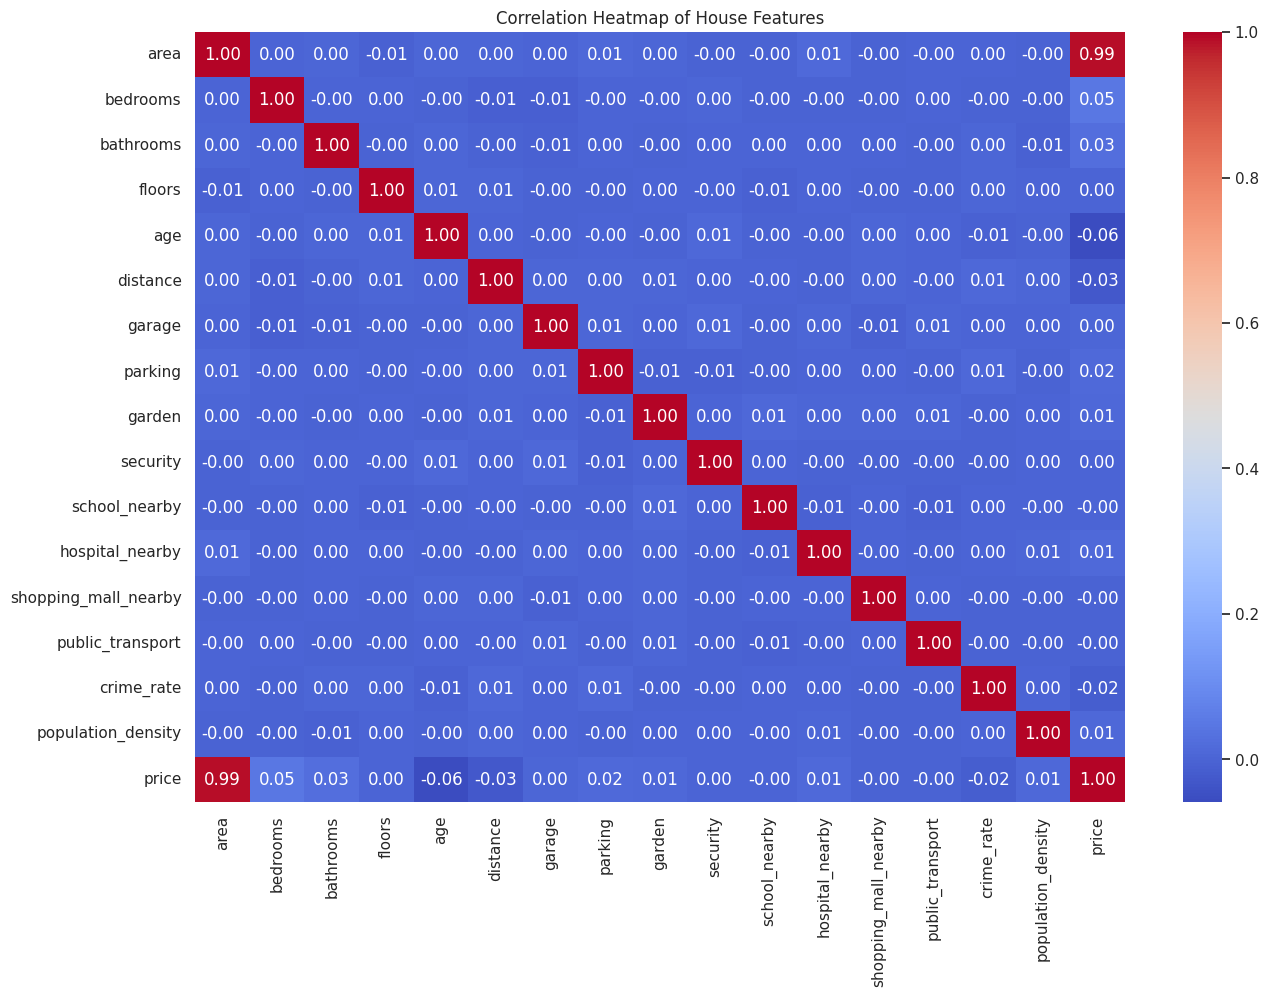

In [ ]:
# Select only numeric columns for correlation
numeric_df = dataset.select_dtypes(include=['float64', 'int64'])
sns.set(style="whitegrid")

plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of House Features')
plt.show()

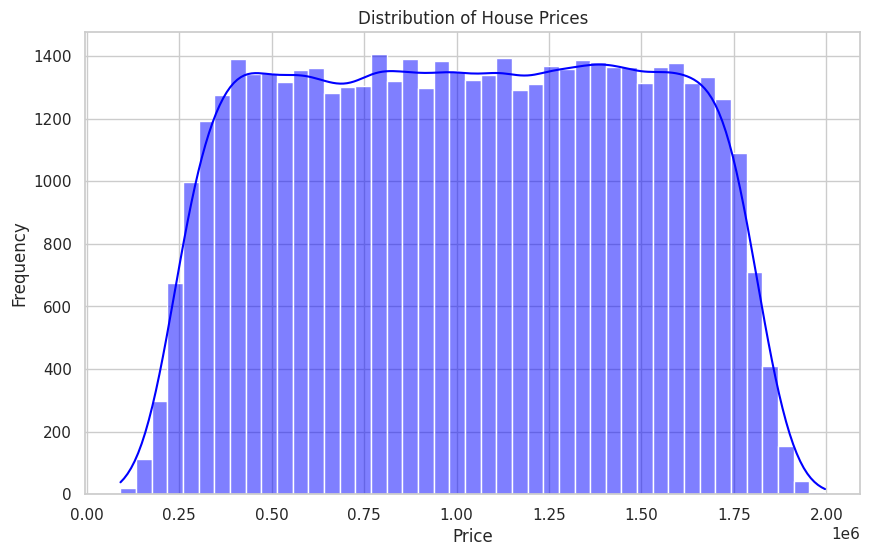

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dataset['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

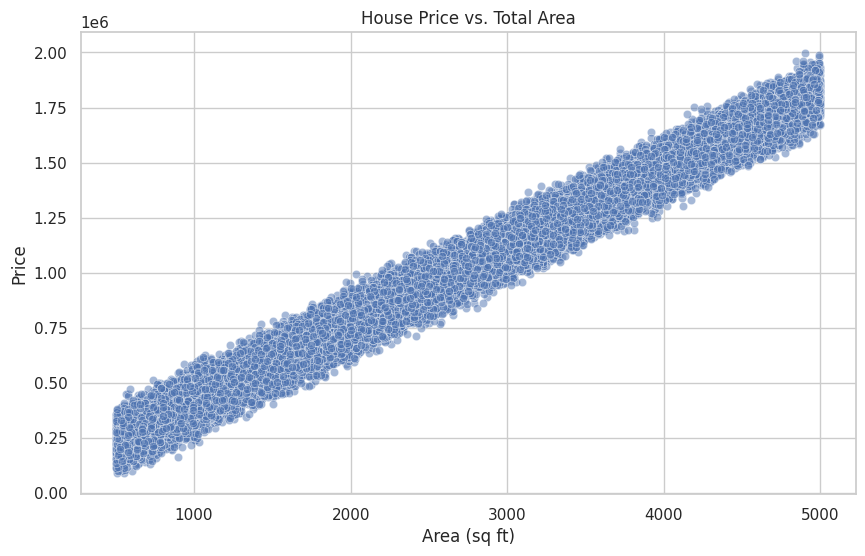

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=dataset, alpha=0.5)
plt.title('House Price vs. Total Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.show()

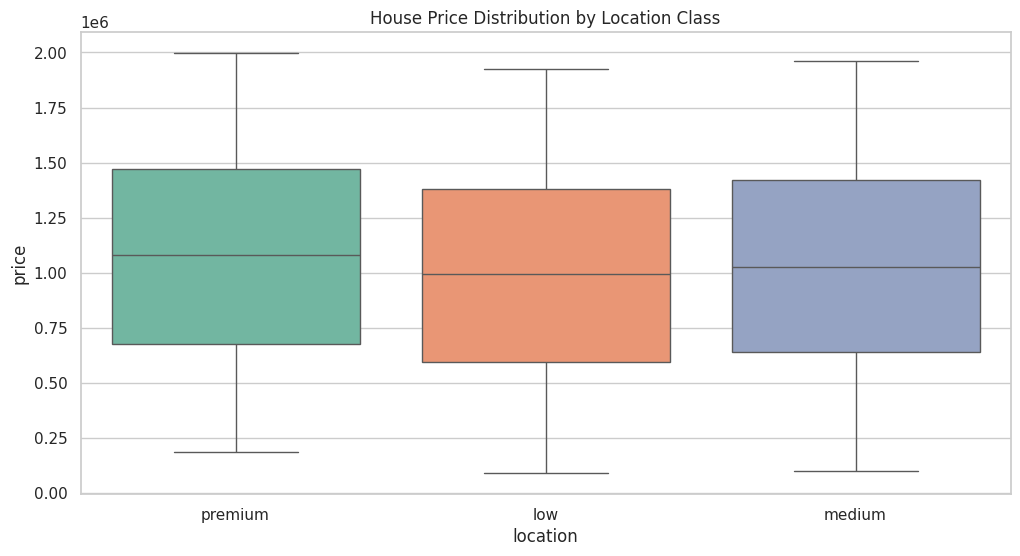

In [ ]:
# Visualization of Location Classes
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='price', data=dataset, palette='Set2', hue='location', legend=False)
plt.title('House Price Distribution by Location Class')
plt.show()

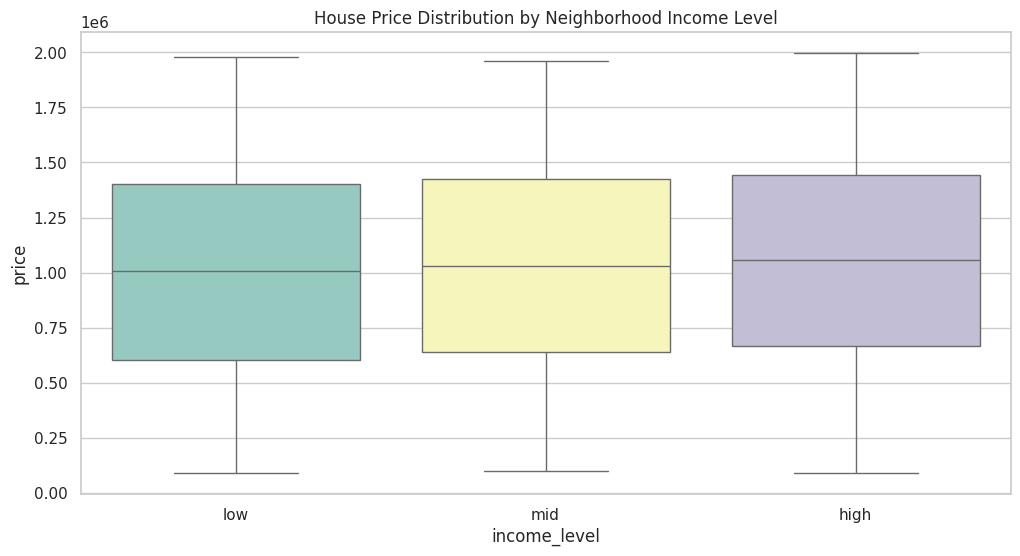

In [ ]:
# Visualization of Income Level Classes
plt.figure(figsize=(12, 6))
sns.boxplot(x='income_level', y='price', data=dataset, palette='Set3', hue='income_level', legend=False)
plt.title('House Price Distribution by Neighborhood Income Level')
plt.show()

In [ ]:
# Define features and target
X = dataset.drop('price', axis=1)
y = dataset['price']

# Identify column types
categorical_features = ['location', 'income_level']
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Create a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing complete. Data split into Train/Test sets.")

Preprocessing complete. Data split into Train/Test sets.


In [ ]:
# 1. Linear Regression (Baseline)
lr_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])

# 2. Ridge Regression (L2 Regularization)
ridge_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))])

# 3. Decision Tree Regressor
dt_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))])

# 4. Multi-layer Perceptron (ANN)
# Uses ReLU activation and Adam optimizer (Gradient Descent variant)
mlp_model = Pipeline(steps=[('preprocessor', preprocessor),
                             ('regressor', MLPRegressor(hidden_layer_sizes=(64, 32),
                                                        activation='relu',
                                                        solver='adam',
                                                        max_iter=500,
                                                        random_state=42))])

# Train all models
models = {
    "Linear Regression": lr_model,
    "Ridge (L2)": ridge_model,
    "Decision Tree": dt_model,
    "MLP (ANN)": mlp_model
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("All models trained successfully.")

Training Linear Regression...
Training Lasso (L1)...
Training Ridge (L2)...
Training Decision Tree...
Training MLP (ANN)...
All models trained successfully.


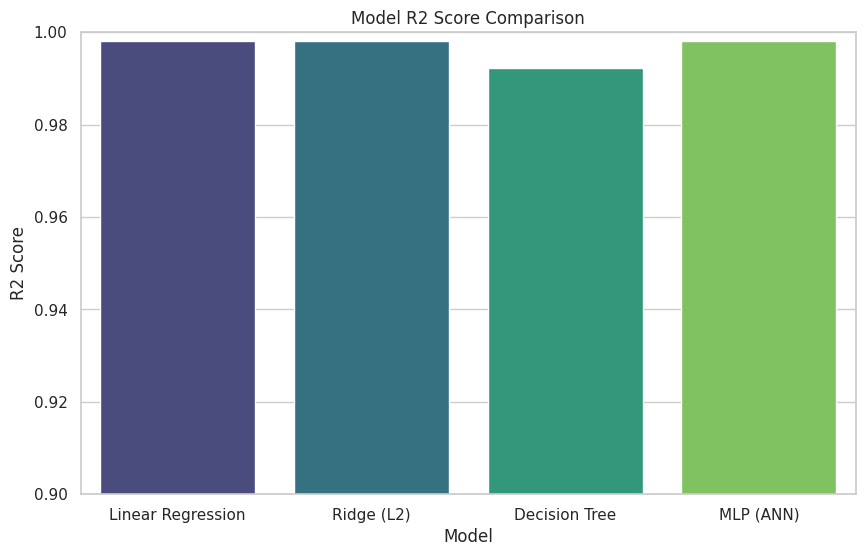

In [ ]:
# Visualization: R2 Score Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Model R2 Score Comparison')
plt.ylim(0.9, 1.0) # Zoom in to see differences
plt.show()

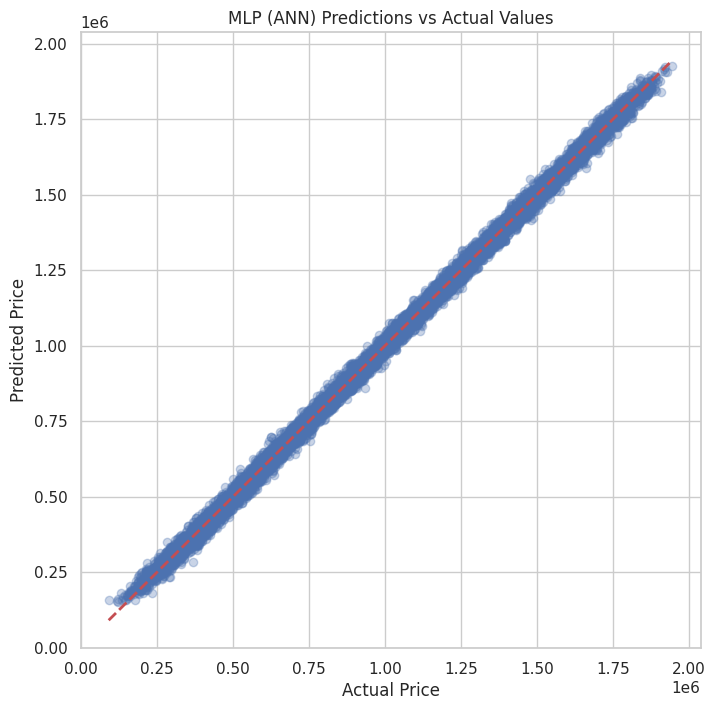

In [ ]:
# Visualization: Actual vs Predicted (for ANN)
y_pred_mlp = mlp_model.predict(X_test)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_mlp, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('MLP (ANN) Predictions vs Actual Values')
plt.show()